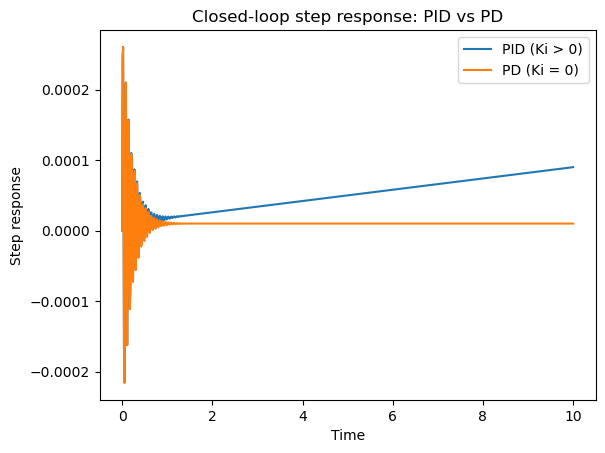

In [1]:
# Plot step responses of a second-order plant with PD vs PID control
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Plant: P(s) = 1 / (a0 s^2 + a1 s + a2)
a0, a1, a2 = 100.0, 1000.0, 1e6

# Controller gains (same except Ki)
Kp, Kd = 10.0, 3.0
Ki_pid = 8.0
Ki_pd = 0.0

# Closed-loop transfer function:
# T(s) = (Kd s^2 + Kp s + Ki) / (a0 s^3 + (a1+Kd)s^2 + (a2+Kp)s + Ki)

def closed_loop_tf(Kp, Kd, Ki):
    num = [Kd, Kp, Ki]
    den = [a0, a1 + Kd, a2 + Kp, Ki]
    return signal.TransferFunction(num, den)

T_pid = closed_loop_tf(Kp, Kd, Ki_pid)
T_pd  = closed_loop_tf(Kp, Kd, Ki_pd)

# Time vector
t = np.linspace(0, 10, 1000)

# Step responses
t1, y_pid = signal.step(T_pid, T=t)
t2, y_pd  = signal.step(T_pd,  T=t)

# Plot (single plot, no explicit colors)
plt.figure()
plt.plot(t1, y_pid, label="PID (Ki > 0)")
plt.plot(t2, y_pd, label="PD (Ki = 0)")
plt.xlabel("Time")
plt.ylabel("Step response")
plt.legend()
plt.title("Closed-loop step response: PID vs PD")
plt.show()


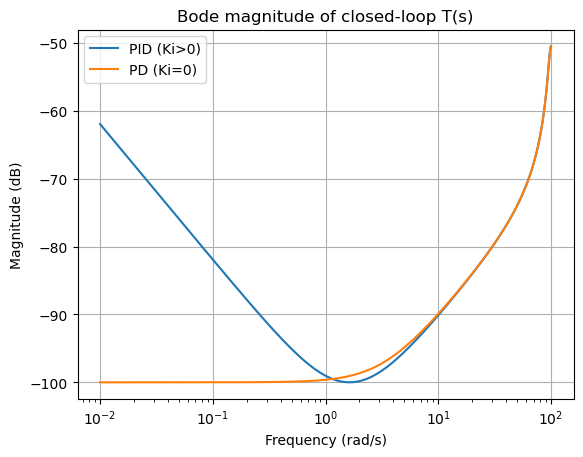

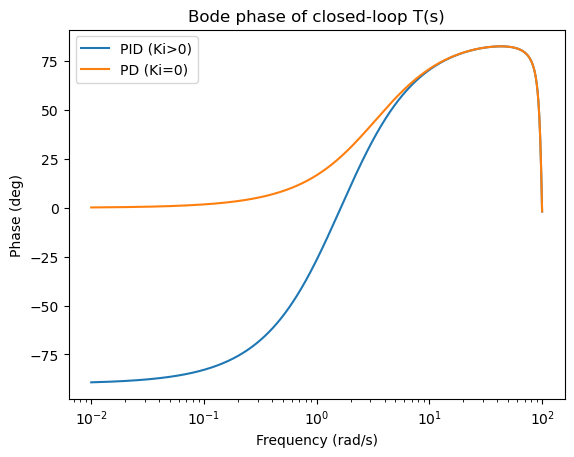

In [2]:
# Frequency range
w = np.logspace(-2, 2, 1000)

w1, mag_pid, phase_pid = signal.bode(T_pid, w)
w2, mag_pd,  phase_pd  = signal.bode(T_pd,  w)

# Magnitude plot
plt.figure()
plt.semilogx(w1, mag_pid, label="PID (Ki>0)")
plt.semilogx(w2, mag_pd,  label="PD (Ki=0)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude (dB)")
plt.title("Bode magnitude of closed-loop T(s)")
plt.grid(True)
plt.legend()
plt.show()

# Phase plot
plt.figure()
plt.semilogx(w1, phase_pid, label="PID (Ki>0)")
plt.semilogx(w2, phase_pd,  label="PD (Ki=0)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Phase (deg)")
plt.title("Bode phase of closed-loop T(s)")
plt.legend()
plt.show()